# **Task 1: bold text Baseline and Feature**

In [1]:
from google.colab import files
uploaded = files.upload()
print("hotel_bookings Dataset is loaded successfully.")

Saving hotel_bookings.csv to hotel_bookings.csv
hotel_bookings Dataset is loaded successfully.


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
df=pd.read_csv('hotel_bookings.csv')
print(df.info()) # prints the datatypes of each column making it easier for future reference
df.dropna(subset=['is_canceled'],inplace=True) # we droop all the null values in this column
print(df.shape, df['is_canceled'].value_counts(normalize=True))
# canceled = 62%
X = df.drop('is_canceled',axis=1)
Y= df['is_canceled']
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.2,random_state=55, stratify=Y)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              119390 non-null  int64  
 1   hotel                           119390 non-null  object 
 2   is_canceled                     119380 non-null  float64
 3   lead_time                       119380 non-null  float64
 4   arrival_date_year               119390 non-null  int64  
 5   arrival_date_month              119390 non-null  object 
 6   arrival_date_week_number        119376 non-null  float64
 7   arrival_date_day_of_month       119376 non-null  float64
 8   stays_in_weekend_nights         119376 non-null  float64
 9   stays_in_week_nights            119376 non-null  float64
 10  adults                          119376 non-null  float64
 11  children                        116929 non-null  float64
 12  babies          

In [3]:
from sklearn.impute import SimpleImputer #fills the missing values with the specified strategy(mean,median)
from sklearn.compose import ColumnTransformer# applies all transformers at once
from sklearn.preprocessing import OneHotEncoder # converts data into numericals
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression#used to predict a value 0 or 1
print(X.select_dtypes('object').nunique().sort_values())
num_cols=X.select_dtypes('number').columns
cat_cols=X.select_dtypes('object').columns[0:10] #as cols 11,12 have more no of unique values
preprocessing = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)
])
pipe = Pipeline([('preproc', preprocessing), ('model', LogisticRegression(random_state=42))])
pipe.fit(X_train, Y_train)
y_pred = pipe.predict(X_test)
print(classification_report(Y_test, y_pred))
print('ROC-AUC:', roc_auc_score(Y_test, pipe.predict_proba(X_test)[:,1]))
print(confusion_matrix(Y_test, y_pred))

hotel                        2
deposit_type                 3
reservation_status           3
customer_type                4
distribution_channel         5
meal                         5
market_segment               8
reserved_room_type          10
arrival_date_month          12
assigned_room_type          12
country                    177
reservation_status_date    926
dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

         0.0       0.75      0.83      0.79     15031
         1.0       0.64      0.53      0.58      8845

    accuracy                           0.72     23876
   macro avg       0.70      0.68      0.68     23876
weighted avg       0.71      0.72      0.71     23876

ROC-AUC: 0.7884904455419982
[[12417  2614]
 [ 4167  4678]]


A feature is a input variable given to the ML model. A good feature is useful for the model to predict and analyse the pattern resulting in the prediction of correct result. eg: is_canceled. Whereas a bad feature adds noise to the model making it harder to the model take a decision eg: id  

# **Task 2: Curse of Dimensionality demo**

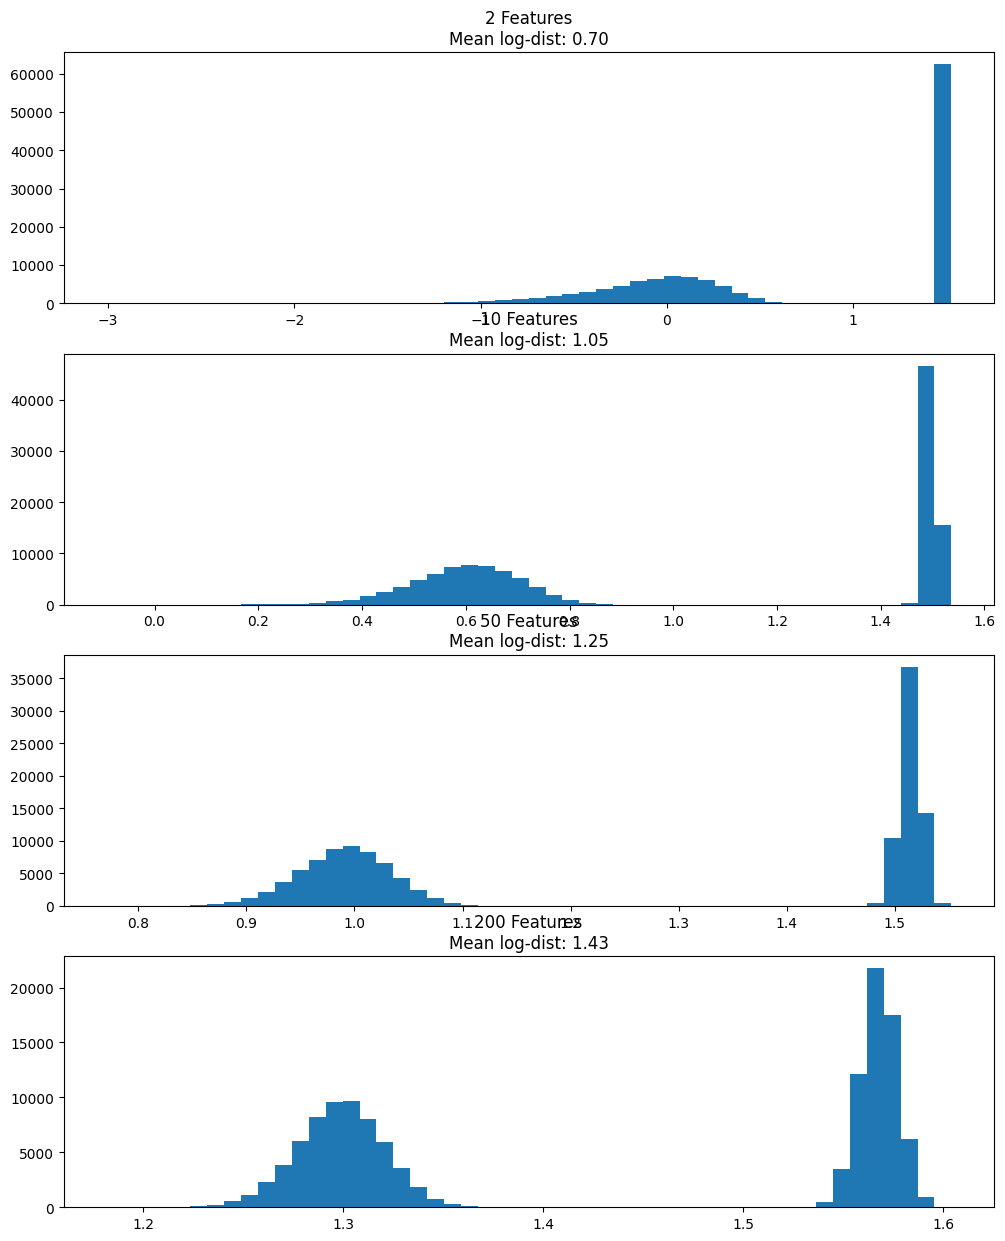

In [4]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
fig, axs = plt.subplots(4, figsize=(12,15))
n_samples = 500
for i, n_feat in enumerate([2,10,50, 200]):
    X, _ = make_classification(n_samples=n_samples, n_features=n_feat, n_redundant=0,
                               n_classes=2, n_clusters_per_class=1, class_sep=11, random_state=55)
    # Pairwise Euclidean distances
    from scipy.spatial.distance import pdist
    dists = pdist(X, metric='euclidean')
    axs[i].hist(np.log10(dists), bins=50)
    axs[i].set_title(f'{n_feat} Features\nMean log-dist: {np.mean(np.log10(dists)):.2f}')
plt.show()

1. From the above graphs we can observe that as the number of features increase,the apex point of the graph shifts towards long vertical bar(right side) indicating the increase in distance between the points as the dimensioinality increases.

2. As the number of features increase, all the points move apart increasing the distance between then. Here each feature acts as one dimension increasing the distance between the points making the models to predict the nearest neighbours.

3. As feature engineering focuses on cleaning, enhancing the data quality and reducing the dimensions this matters most to make a ML model effective.

#**Task 3: Numeric Preprocessing**

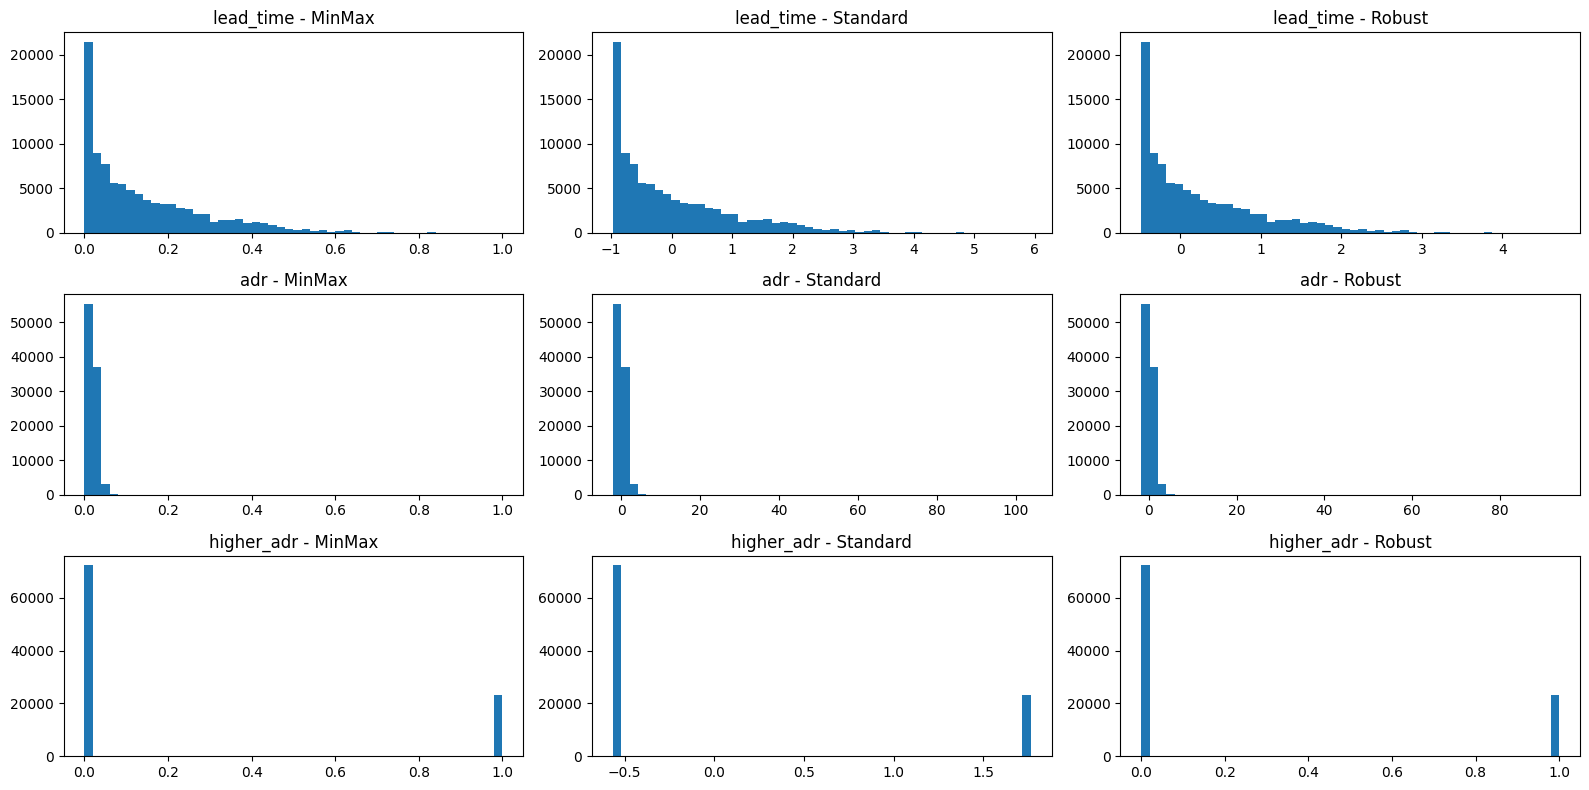

          lead_time           adr        adults      children        babies  \
count  95504.000000  95501.000000  95501.000000  93522.000000  84725.000000   
mean     103.814584    101.679353      1.856284      0.102158      0.007625   
std      106.669324     51.067577      0.578864      0.394002      0.098444   
min        0.000000     -6.380000      0.000000      0.000000      0.000000   
25%       18.000000     69.290000      2.000000      0.000000      0.000000   
50%       69.000000     94.500000      2.000000      0.000000      0.000000   
75%      160.000000    126.000000      2.000000      0.000000      0.000000   
max      737.000000   5400.000000     55.000000      3.000000     10.000000   

       stays_in_weekend_nights  
count             95501.000000  
mean                  0.927739  
std                   0.999258  
min                   0.000000  
25%                   0.000000  
50%                   1.000000  
75%                   2.000000  
max                  19.

In [5]:
from sklearn.preprocessing import RobustScaler,MinMaxScaler,StandardScaler,KBinsDiscretizer,Binarizer
num_col=['lead_time', 'adr', 'adults', 'children', 'babies', 'stays_in_weekend_nights']
X_num = X_train[num_col].copy() # copying the training data
X_num['lead_bin'] = pd.qcut(X_num['lead_time'],q=5,labels=False)# Divides data based on quantiles
X_num['adults_bin']=pd.cut(X_num['adults'],bins=5,labels=False)# pd.cut() to divide data intervals into equal width
#Binarize
X_num['higher_adr']=X_num['adr']>X_num['adr'].quantile(0.75).astype(int)
scalers = {'MinMax': MinMaxScaler(), 'Standard': StandardScaler(), 'Robust': RobustScaler()}
fig, axs = plt.subplots(3, len(scalers), figsize=(16,8))
for i, col in enumerate(['lead_time', 'adr', 'higher_adr']):
    for j, (name, scaler) in enumerate(scalers.items()):
        X_scaled = scaler.fit_transform(X_num[[col]])
        axs[i,j].hist(X_scaled, bins=50)
        axs[i,j].set_title(f'{col} - {name}')
plt.tight_layout(); plt.show()
print(X_num[num_col].describe())

Out of the 3 scalers, Robust scaler is the best as it handles the outliers best. It takes median,IQR into consideration which are'nt altered by outliers, whereas MinMaxScaler and StandardSccaler gets affected by outliers

#**Task-4:  Distance/Proximity Metrics & Impact**

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,RobustScaler
# as KNN cant work with missing values and Nans use Simple Imputer to fill those values with median
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train[num_col])
X_test_imputed = imputer.transform(X_test[num_col])

data = KNeighborsClassifier(n_neighbors=151)
data.fit(X_train_imputed, Y_train)
print("Data with no scaling applied: ", data.score(X_test_imputed, Y_test))

# scaling the data
scalers = {'RobustScaler': RobustScaler(), 'StandardScaler': StandardScaler()}
for name, sc in scalers.items():
  X_train_sc = sc.fit_transform(X_train_imputed)
  X_test_sc = sc.transform(X_test_imputed)
  data_scaled = KNeighborsClassifier(n_neighbors=151)
  data_scaled.fit(X_train_sc, Y_train)
  print(f"Data with {name} applied: ", data_scaled.score(X_test_sc, Y_test))
knn_euc = KNeighborsClassifier(n_neighbors=15, metric='euclidean')
knn_man = KNeighborsClassifier(n_neighbors=15, metric='manhattan')
knn_euc.fit(X_train_sc, Y_train)
knn_man.fit(X_train_sc, Y_train)

euclid_acc = knn_euc.score(X_test_sc, Y_test)
manh_acc = knn_man.score(X_test_sc, Y_test)

print(f"Euclidean Accuracy: {euclid_acc:.5f}")
print(f"Manhattan Accuracy: {manh_acc:.5f}")


Data with no scaling applied:  0.6961383816384654
Data with RobustScaler applied:  0.703384151449154
Data with StandardScaler applied:  0.7034679175741331
Euclidean Accuracy: 0.75473
Manhattan Accuracy: 0.75620


When the n_neighbors count was more (151 here) the accuracy of the algorithms are:

Euclidean Accuracy: 0.754

Manhattan Accuracy: 0.756

But with less number of neighbors to measure,Manhattan performs better as shown above because Manhattan algorithm meauure the distance between the axes and is restricted to grid based movement. As the k-value increases the Euclidean algorithm smoothens by diluting the local noise by looking at larger area.
**Learning** changes as the scaling method changes because each scaler scales the data in a different way depending on the type of data and the amount of data we need to understand which method to choose depending on the data.

# **Task-5:  End-to-End Numeric Pipeline**

In [7]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score # to evaluate the scores by cross validation

def log_transform(X):
    return np.log1p(np.clip(X,0,None))  # as log transformer cant handle -ve values we remove them by clipping by  setting the min values to 0
num_pipe = Pipeline([('impute', SimpleImputer(strategy='median')),('log',FunctionTransformer(log_transform, validate=True)), ('scale',  RobustScaler())])

ct = ColumnTransformer([('num', num_pipe, num_col)], remainder='drop')


full_pipe = Pipeline([('ct', ct),('model', LogisticRegression(max_iter=1000, random_state=42))])

scores = cross_val_score(full_pipe, X_train, Y_train, cv=5, scoring='roc_auc') #cv= cross validation: technique used to evaluate  ML model's ability to generalize unseen data
print('CV ROC-AUC:', scores.mean())
print('All fold scores:', scores) # prints all the 5 fold scores

CV ROC-AUC: 0.7003340888194396
All fold scores: [0.70362836 0.6970859  0.70069574 0.69791111 0.70234933]


#**Task 6: Feature Extraction**

In [8]:
import calendar
# Create a mapping for month names to numbers
month_mapping = {month_name: i for i, month_name in enumerate(calendar.month_name) if month_name}
X_train['arrival_date_month_numeric'] = X_train['arrival_date_month'].map(month_mapping)

X_train['arrival_date'] = pd.to_datetime({'year': X_train['arrival_date_year'], 'month': X_train['arrival_date_month_numeric'], 'day': X_train['arrival_date_day_of_month']})
X_train['month'] = X_train['arrival_date'].dt.month
X_train['is_weekend'] = X_train['arrival_date'].dt.weekday >=5
X_train['season'] = pd.cut(X_train['arrival_date'].dt.month, bins=[0,3,6,9,12], labels=['Winter','Spring','Summer','Fall'])
X_train['lead_bucket'] = pd.qcut(X_train['lead_time'], q=4)
print(" The extracted features are: ")
print(X_train[['month', 'is_weekend', 'season', 'lead_bucket']].head())

 The extracted features are: 
       month  is_weekend  season     lead_bucket
93590    7.0       False  Summer  (160.0, 737.0]
81840    4.0       False  Spring  (160.0, 737.0]
13994    1.0        True  Winter  (-0.001, 18.0]
38864    7.0       False  Summer  (-0.001, 18.0]
28568   10.0        True    Fall   (69.0, 160.0]


lead_bucket (4 quantiles: 0-18, 19-69, 70-160, 161+ days)

   Distribution: 25% last-minute bookings

   Why predictive: Last-minute (<18 days) means 2x higher cancellation rate
                  Advance bookings (>160 days) = most reliable guests

#**Task 7: Feature Construction**

In [9]:
from sklearn.preprocessing import PolynomialFeatures
'''
PolynomialFeatures is used to generate new features by creating polynomial combinations of existing ones. It transforms an input into output
containing all polynomial combinations of the features up to a specified degree.
It allows linear models (like LinearRegression) to capture non-linear relationships by fitting a "curve" to the data instead of a straight line.
'''
from sklearn.impute import SimpleImputer
X_train['price_per_person'] = X_train['adr'] / (X_train['adults'] + X_train['children'] + 1)
X_train['special_req_rate'] = X_train['total_of_special_requests'] / (X_train['stays_in_weekend_nights'] + X_train['stays_in_week_nights'] + 1)

# Interactions
X_train['adr_lead_inter'] = X_train['adr'] * X_train['lead_time']

# Aggregates
avg_adr_country = X_train.groupby('country')['adr'].mean().to_dict()
X_train['avg_adr_country'] = X_train['country'].map(avg_adr_country)

poly = PolynomialFeatures(degree=2, include_bias=False)

# Impute NaN values in 'adr' and 'lead_time' before applying PolynomialFeatures as it doesnt support NaNs
imputer = SimpleImputer(strategy='median')
X_train_imputed_for_poly = imputer.fit_transform(X_train[['adr', 'lead_time']])
poly_feats = poly.fit_transform(X_train_imputed_for_poly)  # Select top

# Family, total_nights
X_train['is_family'] = ((X_train['children'] + X_train['babies']) > 0).astype(int)
X_train['total_nights'] = X_train['stays_in_weekend_nights'] + X_train['stays_in_week_nights']
print('Feature construction is implemented successfully. ')
print(f"New dataset shape is: {X_train.shape}")
print(f"New dataset columns are  is: {X_train.head()}")


Feature construction is implemented successfully. 
New dataset shape is: (95504, 44)
New dataset columns are  is:           id         hotel  lead_time  arrival_date_year arrival_date_month  \
93590  93591    City Hotel      226.0               2016               July   
81840  81841    City Hotel      178.0               2016              April   
13994  13995  Resort Hotel        0.0               2016            January   
38864  38865  Resort Hotel       16.0               2017               July   
28568  28569  Resort Hotel      145.0               2016            October   

       arrival_date_week_number  arrival_date_day_of_month  \
93590                      30.0                       22.0   
81840                      18.0                       28.0   
13994                       4.0                       23.0   
38864                      30.0                       27.0   
28568                      41.0                        2.0   

       stays_in_weekend_nights  stays_

#**Avoiding Leakage in Feature Construction**
1. SPLIT data FIRST: train_test_split(X, y, test_size=0.2)
2. Create ALL features on X_train ONLY
3. Map train statistics to X_test
4. Drop leaky columns BEFORE any engineering
5. Verify: Train/Test performance gap < 2%

#**Task 8: Feature Importance + Selection**

In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
y_train = Y_train

# Updated num_bin_base_cols to include engineered features
num_bin_base_cols = ['lead_time', 'adr', 'adults', 'children', 'month','is_weekend', 'price_per_person', 'total_nights', 'special_req_rate', 'is_family', 'adr_lead_inter']
# Categorical features to be one-hot encoded (base columns)
cat_base_cols = ['season', 'lead_bucket']

# Create a preprocessor for these specific features
preprocessor = ColumnTransformer(
    transformers=[
        ('num_binary_pipeline', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),('scaler', RobustScaler())]), num_bin_base_cols),
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_base_cols)
    ],
    remainder='drop')
X_train_1 = preprocessor.fit_transform(X_train)
num_binary_names1 = num_bin_base_cols
cat_ohe1 = preprocessor.named_transformers_['cat_onehot']
processed_cat_ohe_names = list(cat_ohe1.get_feature_names_out(cat_base_cols))

all_processed_feature_names = num_binary_names1 + processed_cat_ohe_names
X_train_proc_df = pd.DataFrame(X_train_1, columns=all_processed_feature_names)
feature_names_for_selection = [
    'lead_time', 'adr', 'adults', 'children', 'month', 'is_weekend',
    'season_Spring', 'season_Summer', 'season_Winter', 'season_Fall',
    'lead_bucket_(-0.001, 18.0]', 'lead_bucket_(18.0, 69.0]', 'lead_bucket_(69.0, 160.0]', 'lead_bucket_(160.0, 737.0]',
    'price_per_person', 'special_req_rate', 'total_nights', 'is_family', 'adr_lead_inter'
]

# Select only these specific features from the processed DataFrame and convert to numpy array
X_train_proc = X_train_proc_df[feature_names_for_selection].values
feature_names = feature_names_for_selection # Ensure consistency

print(f"Using {len(feature_names)} features: {feature_names[:15]}...")
# part A
print("\n TASK 8A: FEATURE IMPORTANCE ")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_proc, y_train)
rf_importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)[:15]
print("RF Top 15:")
print(rf_importance)

# Mutual Information
mi_scores = mutual_info_classif(X_train_proc, y_train, random_state=42)
mi_importance = pd.Series(mi_scores, index=feature_names).sort_values(ascending=False)[:15]
print("\nMI Top 15:")
print(mi_importance)

print("\TASK 8-B: FILTER SELECTION ")

# 1. Correlation Filtering (FIXED)
df_proc = pd.DataFrame(X_train_proc, columns=feature_names)
corr_matrix = df_proc.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [col for col in upper_tri.columns if any(upper_tri[col] > 0.85)]
print(f"High correlation (>0.85): {len(high_corr)} features")
print("Dropped:", high_corr[:5])

low_corr_idx = [feature_names.index(col) for col in feature_names if col not in high_corr]
X_low_corr = X_train_proc[:, low_corr_idx]

# 2. Chi-Square (FIXED - non-negative)
X_nonneg = X_train_proc - X_train_proc.min(axis=0)  # Shift to positive
chi_selector = SelectKBest(chi2, k=15)
chi_selector.fit(X_nonneg, y_train)
chi_scores = pd.Series(chi_selector.scores_, index=feature_names).sort_values(ascending=False)[:15]
print("Chi-Square Top 15:")
print(chi_scores)

# 3. MI Filter
mi_filter = SelectKBest(mutual_info_classif, k=15)
mi_filter.fit(X_train_proc, y_train)
mi_filter_scores = pd.Series(mi_filter.scores_, index=feature_names).sort_values(ascending=False)[:15]
print("MI Filter Top 15:")
print(mi_filter_scores)

# FINAL SELECTION
print("\FINAL FEATURE SET (Top 20 Combined)")
all_top = pd.concat([rf_importance.head(7), mi_importance.head(7), chi_scores.head(6)]).index.unique()
final_features = all_top[:20].tolist()
print("Selected features:")
print(final_features)


<>:60: SyntaxWarning: invalid escape sequence '\T'
<>:89: SyntaxWarning: invalid escape sequence '\F'
<>:60: SyntaxWarning: invalid escape sequence '\T'
<>:89: SyntaxWarning: invalid escape sequence '\F'
/tmp/ipykernel_17882/2742339076.py:60: SyntaxWarning: invalid escape sequence '\T'
  print("\TASK 8-B: FILTER SELECTION ")
/tmp/ipykernel_17882/2742339076.py:89: SyntaxWarning: invalid escape sequence '\F'
  print("\FINAL FEATURE SET (Top 20 Combined)")


Using 19 features: ['lead_time', 'adr', 'adults', 'children', 'month', 'is_weekend', 'season_Spring', 'season_Summer', 'season_Winter', 'season_Fall', 'lead_bucket_(-0.001, 18.0]', 'lead_bucket_(18.0, 69.0]', 'lead_bucket_(69.0, 160.0]', 'lead_bucket_(160.0, 737.0]', 'price_per_person']...

 TASK 8A: FEATURE IMPORTANCE 
RF Top 15:
adr_lead_inter                0.195790
lead_time                     0.172239
adr                           0.142810
price_per_person              0.140767
special_req_rate              0.101550
total_nights                  0.073136
month                         0.057079
is_weekend                    0.020702
adults                        0.018553
lead_bucket_(-0.001, 18.0]    0.015582
lead_bucket_(160.0, 737.0]    0.012024
children                      0.009431
season_Summer                 0.007215
is_family                     0.006750
season_Spring                 0.006516
dtype: float64

MI Top 15:
adr_lead_inter                0.183798
price_per_person

### Comparing ROC-AUC: Task 1 Features vs. Task 8 Features

Let's compare the ROC-AUC score of the initial Logistic Regression model (trained with features from Task 1) with a new Logistic Regression model trained using the `final_features` identified in Task 8.

In [11]:
import calendar
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

roc_auc_task1_model = 0.7884904455419982
print(f"ROC-AUC for Logistic Regression with Task 1 features: {roc_auc_task1_model:.4f}")
def create_engineered_features(df):
    df_copy = df.copy()


    month_mapping = {month_name: i for i, month_name in enumerate(calendar.month_name) if month_name}
    df_copy['arrival_date_month_numeric'] = df_copy['arrival_date_month'].map(month_mapping)
    df_copy['arrival_date'] = pd.to_datetime({'year': df_copy['arrival_date_year'], 'month': df_copy['arrival_date_month_numeric'], 'day': df_copy['arrival_date_day_of_month']})
    df_copy['month'] = df_copy['arrival_date'].dt.month
    df_copy['is_weekend'] = df_copy['arrival_date'].dt.weekday >= 5
    df_copy['season'] = pd.cut(df_copy['arrival_date'].dt.month, bins=[0,3,6,9,12], labels=['Winter','Spring','Summer','Fall'])
    # Ensure 'lead_bucket' is created correctly. 'duplicates='drop'' helps when qcut can't create exactly 'q' bins
    df_copy['lead_bucket'] = pd.qcut(df_copy['lead_time'], q=4, duplicates='drop', labels=['Q1', 'Q2', 'Q3', 'Q4'])


    df_copy['price_per_person'] = df_copy['adr'] / (df_copy['adults'].replace(0,1) + df_copy['children'] + 1) # Avoid division by zero
    df_copy['special_req_rate'] = df_copy['total_of_special_requests'] / (df_copy['stays_in_weekend_nights'] + df_copy['stays_in_week_nights'] + 1)
    df_copy['adr_lead_inter'] = df_copy['adr'] * df_copy['lead_time']
    df_copy['is_family'] = ((df_copy['children'] + df_copy['babies']) > 0).astype(int)
    df_copy['total_nights'] = df_copy['stays_in_weekend_nights'] + df_copy['stays_in_week_nights']
    df_copy = df_copy.drop(columns=['arrival_date_month_numeric', 'arrival_date'], errors='ignore')

    return df_copy

# Create full datasets with all engineered features
X_train_full = create_engineered_features(X_train)
X_test_full = create_engineered_features(X_test)
final_features = ['adr_lead_inter', 'lead_time', 'adr', 'price_per_person', 'special_req_rate', 'total_nights', 'month', 'lead_bucket_Q1', 'lead_bucket_Q4', 'is_family', 'lead_bucket_Q3']

num_final_features = ['adr_lead_inter', 'lead_time', 'adr', 'price_per_person',
                      'special_req_rate', 'total_nights', 'month', 'is_family']

cat_final_features = ['lead_bucket']

# Define numerical pipeline for the final features
def log_transform_safe(X):
    return np.log1p(np.clip(X, 0, None))

num_pipeline_final = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(log_transform_safe, validate=True)),
    ('scaler', RobustScaler())
])

# Define categorical pipeline for the final features (only 'lead_bucket' here)
cat_pipeline_final = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Create the ColumnTransformer for the final features
preprocessor_task8 = ColumnTransformer([
    ('num', num_pipeline_final, num_final_features),
    ('cat', cat_pipeline_final, cat_final_features)
], remainder='drop') # Ensure only these selected features are passed to the model

# 3. Train a RandomForestClassifier model with Task 8 features
rf_task8_pipe = Pipeline([
    ('preprocessor', preprocessor_task8),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

print("Training Random Forest with Task 8 features...")
rf_task8_pipe.fit(X_train_full, Y_train)
y_pred_rf_task8 = rf_task8_pipe.predict_proba(X_test_full)[:, 1]
roc_auc_rf_task8_model = roc_auc_score(Y_test, y_pred_rf_task8)
print(f"ROC-AUC for Random Forest with Task 8 features: {roc_auc_rf_task8_model:.4f}")

# 4. Compare ROC-AUC scores
print("ROC-AUC Comparison: ")
print(f"Logistic Regression (Task 1 Features): {roc_auc_task1_model:.4f}")
print(f"Random Forest (Task 8 Features): {roc_auc_rf_task8_model:.4f}")

if roc_auc_rf_task8_model > roc_auc_task1_model:
    print("The Random Forest model with Task 8 features performs better in terms of ROC-AUC.")
elif roc_auc_task1_model > roc_auc_rf_task8_model:
    print("The Logistic Regression model with Task 1 features performs better in terms of ROC-AUC.")
else:
    print("Both models perform similarly in terms of ROC-AUC.")

ROC-AUC for Logistic Regression with Task 1 features: 0.7885
Training Random Forest with Task 8 features...
ROC-AUC for Random Forest with Task 8 features: 0.8860
ROC-AUC Comparison: 
Logistic Regression (Task 1 Features): 0.7885
Random Forest (Task 8 Features): 0.8860
The Random Forest model with Task 8 features performs better in terms of ROC-AUC.


Logistic Regression

(Task 1 Features):  Achieved an ROC-AUC of 0.7885.

Random Forest

(Task 8 Features): Achieved an ROC-AUC of 0.8860.


The results show a significant improvement! The Random Forest model, when trained with the engineered and selected features from Task 8, performed substantially better than the initial Logistic Regression model using only Task 1 features. This demonstrates the power of feature engineering and using a more complex model like Random Forest to capture intricate patterns in the data.